### Four different input settings:
1. Basic: $$F^\mathrm{ST}((\hat{v}, h(\tilde{v})) = f_v,$$ $$\mathfrak{B}(\hat{v}, h(\hat{v}), f_v, y^\dag) = v.$$
2. Noise in ST (NST): $$\hat{y} = h(\hat{v}) + \eta,$$ $$F^\mathrm{ST}((\hat{v}, \hat{y}) = f_v,$$ $$\mathfrak{B}(\hat{v}, h(\hat{v}), f_v, y^\dag) = v.$$
3. Noise in MLP (NMLP): $$\hat{y} = h(\hat{v}) + \eta,$$ $$F^\mathrm{ST}((\hat{v}, h(\hat{v}) = f_v, $$ $$\mathfrak{B}(\hat{v}, h(\hat{v}), f_v, y^\dag - \hat{y}) = v.$$
4. NST \& NMLP: $$\hat{y} = h(\hat{v}) + \eta,$$ $$F^\mathrm{ST}((\hat{v}, \hat{y}) = f_v, $$ $$\mathfrak{B}(\hat{v}, h(\hat{v}), f_v, y^\dag - \hat{y}) = v.$$

### Evaluation

Here, we aim to investigate whether the function $\mathfrak{B}$ exhibits an approximately linear relationship with its final input, i.e., the innovation term ($y^\dag$ or $y^\dag - \hat{y}$).

To test this hypothesis, we generate 50,000 random input-output pairs for the function $\mathfrak{B}$. We then fit a linear least squares model to this data. The linearity is quantified by the coefficient of determination, $R^2$.

The $R^2$ value is defined as:
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (v_i - \tilde{v}_i)^2}{\sum_{i=1}^{n} (v_i - \bar{v})^2}$$
where:
- $v_i$ is the actual output from $\mathfrak{B}$.
- $\tilde{v}_i$ is the value predicted by the linear least squares model.
- $\bar{v}$ is the mean of the actual outputs.
- $n=50000$ is the total number of samples.

We define the degree of linearity based on the following criteria:
- **Approximately linear:** if $R^2 > 0.9$
- **Highly linear:** if $R^2 > 0.95$


### Linear Problem

In this setup, the state dimension is 10, with the state vector defined as $v = (v_1, v_2, \dots, v_{10})$. The observation dimension is 5. The observation $y$ consists of a subset of the state variables: $y = (v_1, v_3, v_5, v_7, v_9)$.

| **Method** | Linear-Base | Linear-NST | Linear-NMLP | Linear-NST&NMLP |
| :-------------- | :---------- | :--------- | :---------- | :-------------- |
| **$R^2$ Value** | 0.962415    | 0.985526   | 0.984611    | 0.974562        |

### Lorenz '63

State v = (x,y,z), observation is just x.

| **Method** | Linear-Base | Linear-NST | Linear-NMLP | Linear-NST&NMLP |
| :-------------- | :---------- | :--------- | :---------- | :-------------- |
| **$R^2$ Value** | 0.632937    | 0.891406   | 0.472108    | 0.565895        |

In [3]:
cd ..

/home/bhchen/LearnKalmanGain


In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def display_images_in_a_row(image_paths):
    """
    Reads and displays multiple images in a single row.

    Args:
        image_paths: A list of file paths for the images.
    """
    # Get the number of images
    num_images = len(image_paths)

    # Create a figure and a set of subplots.
    # figsize is optional, adjusts the size of the overall figure.
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))

    # If there is only one image, axes will not be an array, so we make it one.
    if num_images == 1:
        axes = [axes]

    # Loop through the image paths and display each image.
    for i, image_path in enumerate(image_paths):
        try:
            # Read the image using mpimg.imread()
            img = mpimg.imread(image_path)
            # Display the image on the i-th subplot
            axes[i].imshow(img)
            # Turn off the axis labels for a cleaner look
            axes[i].axis('off')
        except FileNotFoundError:
            print(f"Error: The file at '{image_path}' was not found.")
            axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
            axes[i].axis('off')


    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()


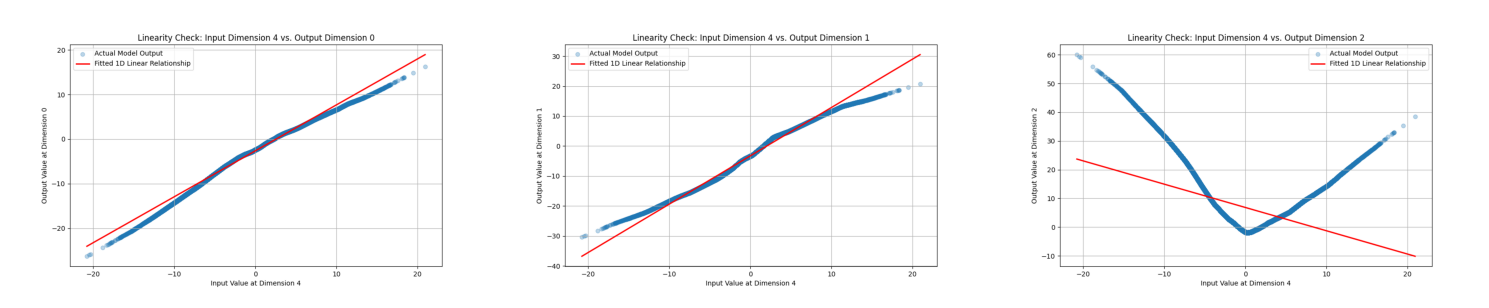

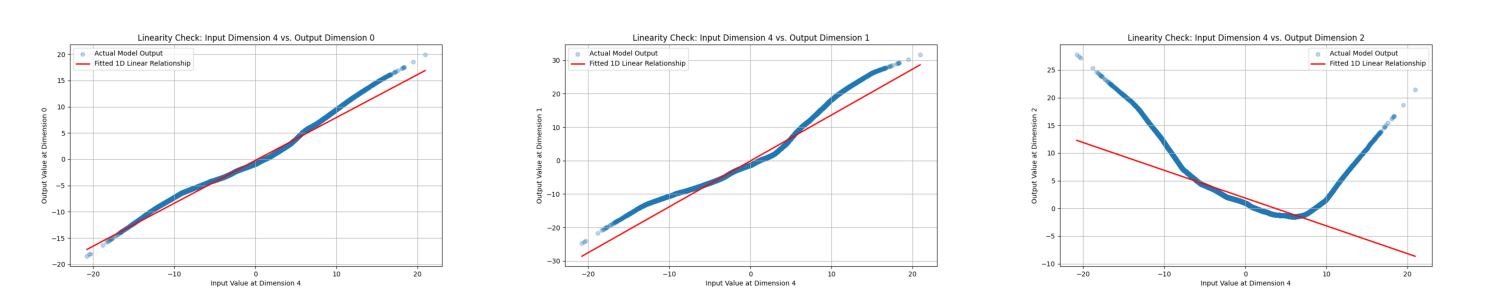

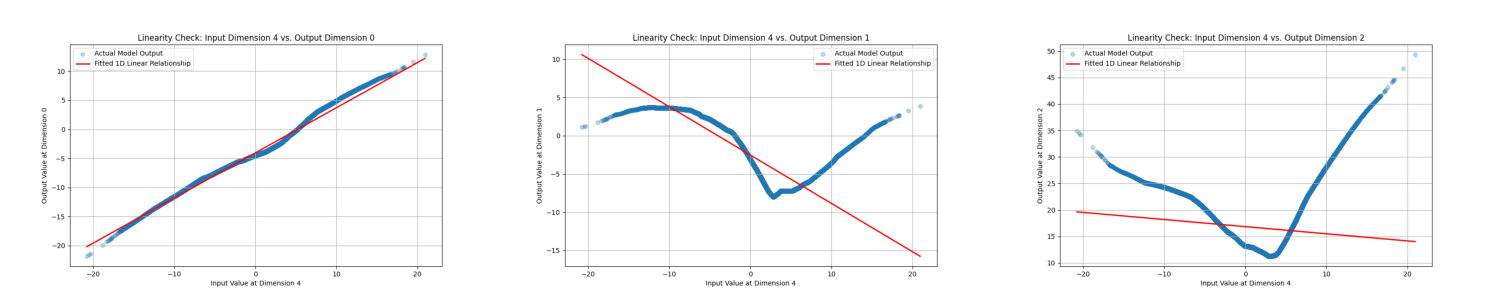

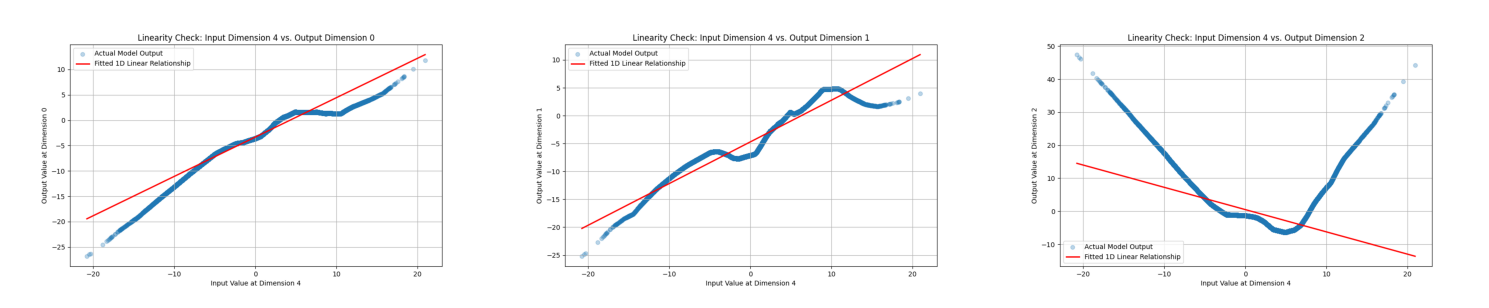

In [5]:
paths = ["save/EtE-LinearCheck/2025-07-06_12-24lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
        "save/EtE-LinearCheck/2025-07-09_19-08lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst",
        "save/EtE-LinearCheck/2025-07-09_23-25lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nimlp",
        "save/EtE-LinearCheck/2025-07-09_23-25lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst_nimlp"]

images = ["linearity_vis_input_4_vs_output_0",
        "linearity_vis_input_4_vs_output_1",
        "linearity_vis_input_4_vs_output_2"]

for folder in paths:
        image_paths = [f"{folder}/{image}.png" for image in images]
        display_images_in_a_row(image_paths)

### Lorenz '63

State v = (x,y,z), observation is just x.

**Check the linearity against |x|**

| **Method** | Linear-Base | Linear-NST | Linear-NMLP | Linear-NST&NMLP |
| :-------------- | :---------- | :--------- | :---------- | :-------------- |
| **$R^2$ Value** | 0.984115    | 0.941829   | 0.789891    | 0.514693       |

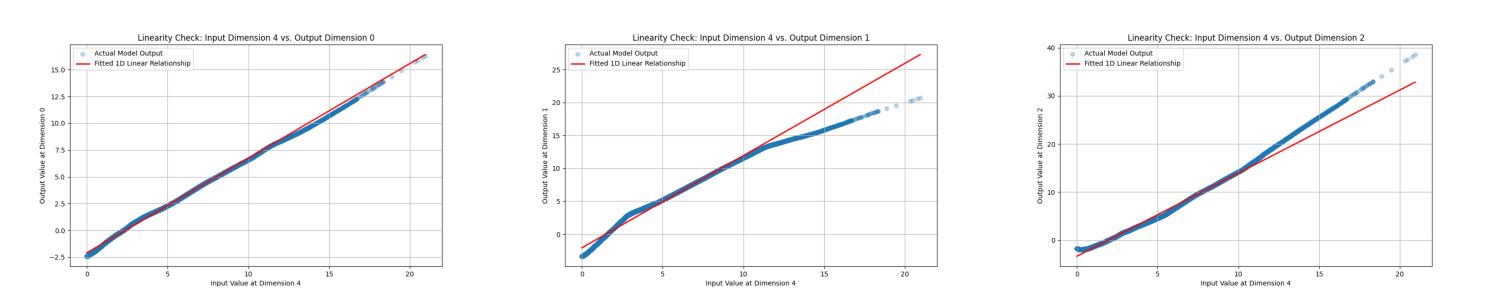

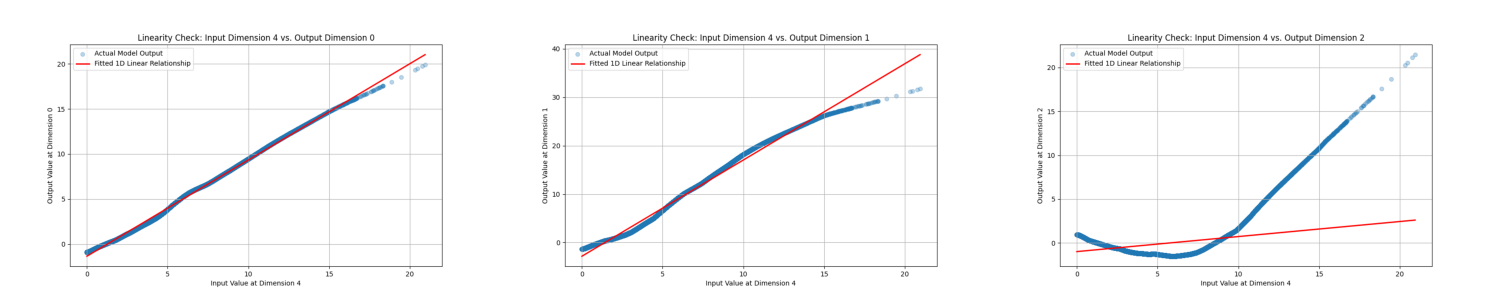

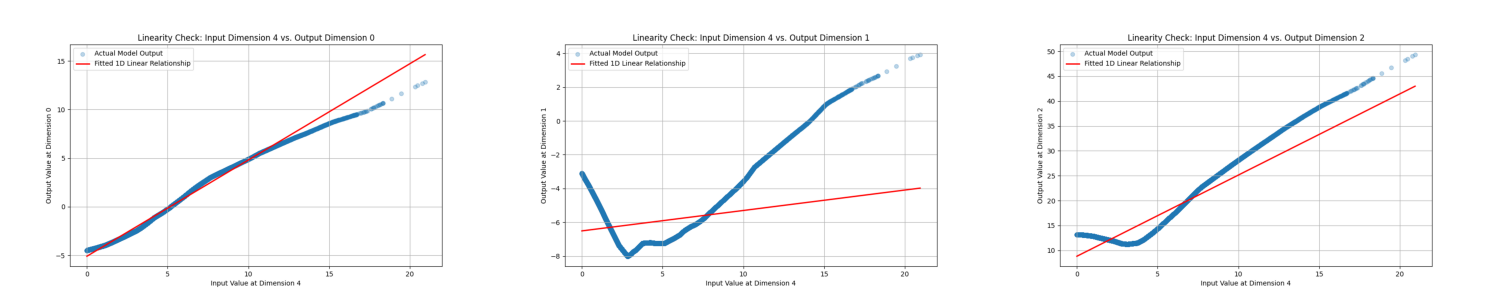

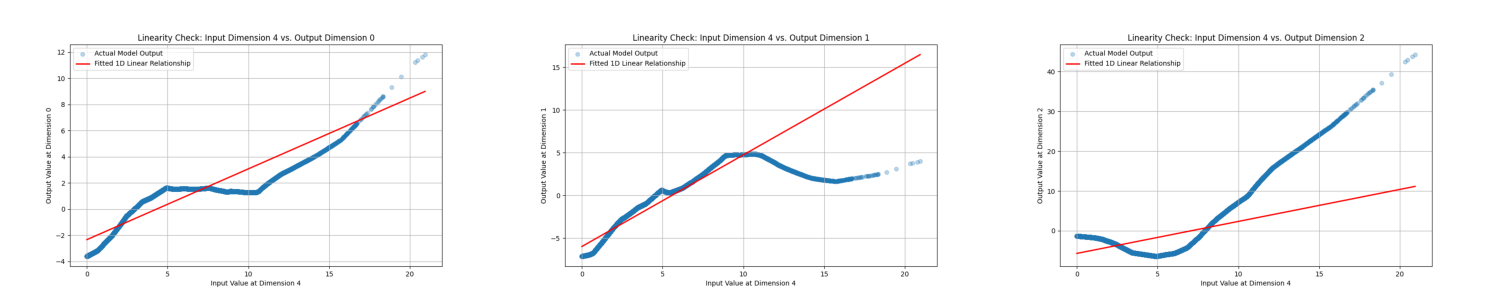

In [6]:
paths = ["save/EtE-LinearCheck/2025-07-06_12-24lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
        "save/EtE-LinearCheck/2025-07-09_19-08lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst",
        "save/EtE-LinearCheck/2025-07-09_23-25lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nimlp",
        "save/EtE-LinearCheck/2025-07-09_23-25lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst_nimlp"]

images = ["linearity_vis_input_4_vs_output_0_abs",
        "linearity_vis_input_4_vs_output_1_abs",
        "linearity_vis_input_4_vs_output_2_abs"]

for folder in paths:
        image_paths = [f"{folder}/{image}.png" for image in images]
        display_images_in_a_row(image_paths)